In [1]:
import tensorflow as tf
from tensorflow import keras

In [2]:
mnist = keras.datasets.mnist
(x_train_full, y_train_full), (x_test, y_test) = mnist.load_data()


11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [3]:
X_valid, X_train = x_train_full[:5000]/255.0, x_train_full[5000:]/255.0
y_valid, y_train = y_train_full[:5000], y_train_full[5000:]

In [4]:
class_names = ['0','1','2','3','4','5','6','7','8','9']
class_names[y_train[0]]


'7'

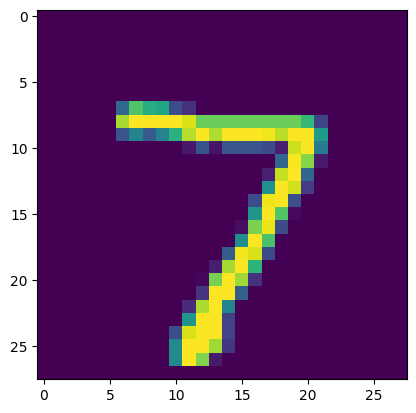

In [5]:
import matplotlib.pyplot as plt
%matplotlib inline
img = x_test[0]
plt.imshow(img)

In [6]:
model = keras.models.Sequential([
    keras.layers.Flatten(input_shape=[28, 28]),
    keras.layers.Dense(392, activation='relu'),
    keras.layers.Dense(196, activation='relu'),
    keras.layers.Dense(10, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [7]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 392)            │       307,720 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 196)            │        77,028 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         1,970 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 386,718 (1.48 MB)

 Trainable params: 386,718 (1.48 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.layers
hidden1 = model.layers[1]
hidden1.name
layer1 = model.get_layer(hidden1.name)
weights,biases = hidden1.get_weights()
weights

biases.shape
biases

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0.

In [8]:
model.compile(loss='sparse_categorical_crossentropy',
              optimizer='sgd',
              metrics=['accuracy'])

In [10]:
history = model.fit(X_train, y_train, epochs=10,
                    validation_data=(X_valid, y_valid))

Epoch 1/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 15s 8ms/step - accuracy: 0.8902 - loss: 0.3970 - val_accuracy: 0.9250 - val_loss: 0.2738
Epoch 2/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9203 - loss: 0.2755 - val_accuracy: 0.9386 - val_loss: 0.2250
Epoch 3/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 17s 10ms/step - accuracy: 0.9379 - loss: 0.2234 - val_accuracy: 0.9458 - val_loss: 0.1921
Epoch 4/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 13s 5ms/step - accuracy: 0.9472 - loss: 0.1922 - val_accuracy: 0.9512 - val_loss: 0.1720
Epoch 5/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9537 - loss: 0.1637 - val_accuracy: 0.9574 - val_loss: 0.1516
Epoch 6/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9570 - loss: 0.1498 - val_accuracy: 0.9616 - val_loss: 0.1370
Epoch 7/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9616 - loss: 0.1359 - val_accuracy: 0.9644 - val_loss: 0.1293
Epoch 8/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9660 - loss: 0.122

In [11]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    f1_score,
    precision_score,
    recall_score
)

def evaluate_classification(y_true, y_pred, output_prefix="model_eval"):

    # =========================
    # Preparación de etiquetas
    # =========================
    y_pred_classes = np.argmax(y_pred, axis=1)
    y_true_flat = y_true.reshape(-1)

    num_classes = y_pred.shape[1]

    # =========================
    # Métricas principales
    # =========================
    accuracy = accuracy_score(y_true_flat, y_pred_classes)
    precision_macro = precision_score(y_true_flat, y_pred_classes, average="macro")
    recall_macro = recall_score(y_true_flat, y_pred_classes, average="macro")
    f1_macro = f1_score(y_true_flat, y_pred_classes, average="macro")

    loss_fn = tf.keras.losses.SparseCategoricalCrossentropy()
    loss = loss_fn(y_true, y_pred).numpy()

    top5 = tf.keras.metrics.SparseTopKCategoricalAccuracy(k=min(5, num_classes))
    top5.update_state(y_true, y_pred)
    top5_acc = top5.result().numpy()

    # =========================
    # Guardar métricas en CSV
    # =========================
    metrics_dict = {
        "Accuracy": accuracy,
        "Precision_macro": precision_macro,
        "Recall_macro": recall_macro,
        "F1_macro": f1_macro,
        "Loss": loss,
        "Top5_accuracy": top5_acc
    }

    df_metrics = pd.DataFrame([metrics_dict])
    df_metrics.to_csv(f"{output_prefix}_metrics.csv", index=False)

    # =========================
    # Classification Report
    # =========================
    report = classification_report(y_true_flat, y_pred_classes, output_dict=True)
    df_report = pd.DataFrame(report).transpose()
    df_report.to_csv(f"{output_prefix}_classification_report.csv")

    # =========================
    # Matriz de Confusión
    # =========================
    cm = confusion_matrix(y_true_flat, y_pred_classes)

    plt.figure(figsize=(8,6))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title("Confusion Matrix")
    plt.tight_layout()
    plt.savefig(f"{output_prefix}_confusion_matrix.svg", format="svg")
    plt.close()

    # =========================
    # Matriz Normalizada
    # =========================
    cm_norm = cm.astype("float") / cm.sum(axis=1)[:, np.newaxis]

    plt.figure(figsize=(8,6))
    sns.heatmap(cm_norm, annot=True, fmt=".2f", cmap="Blues")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title("Normalized Confusion Matrix")
    plt.tight_layout()
    plt.savefig(f"{output_prefix}_confusion_matrix_normalized.svg", format="svg")
    plt.close()

    plt.figure(figsize=(10,4))

    for i in range(10):
        plt.subplot(2,5,i+1)
        plt.imshow(predict_x[i])
        plt.title(f"True: {y_true_flat[i]}\nPred: {y_pred_classes[i]}")
        plt.axis("off")

    plt.tight_layout()
    plt.savefig(f"{output_prefix}_ten_images.svg", format="svg")
    plt.close()

    print("Evaluación completada y archivos guardados.")
    print(metrics_dict)

    return metrics_dict


In [19]:
predict_x = x_test[0:100]
y_true =  y_test[0:100]

y_pred = model(x_test, training=False).numpy()

evaluate_classification(y_test, y_pred, output_prefix="MLP")


Evaluación completada y archivos guardados.
{'Accuracy': 0.9667, 'Precision_macro': 0.9671092812740119, 'Recall_macro': 0.9661750586804345, 'F1_macro': 0.9663944423011767, 'Loss': np.float32(0.5272783), 'Top5_accuracy': np.float32(1.0)}


{'Accuracy': 0.9667,
 'Precision_macro': 0.9671092812740119,
 'Recall_macro': 0.9661750586804345,
 'F1_macro': 0.9663944423011767,
 'Loss': np.float32(0.5272783),
 'Top5_accuracy': np.float32(1.0)}

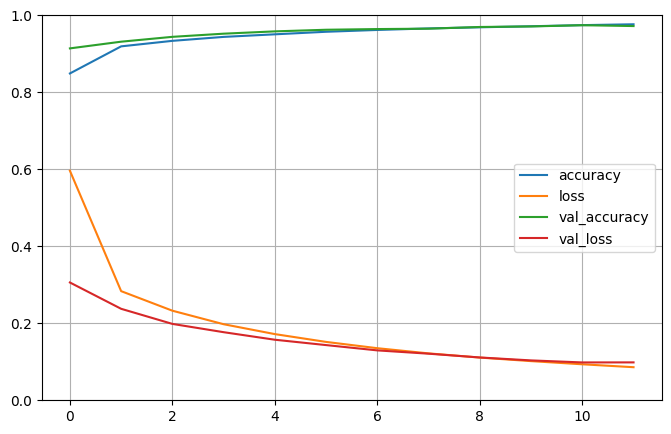

In [ ]:
import pandas as pd
import numpy as np

pd.DataFrame(history.history).plot(figsize=(8,5))
plt.grid(True)
plt.gca().set_ylim(0,1) # Set the vertical range to [0,1]
plt.show()

In [ ]:
y_preds = model.predict(x_test)



313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


In [ ]:
import pandas as pd
import numpy as np
arr = np.array(y_preds)
df = pd.DataFrame(arr, columns=class_names)

In [ ]:
df = df.round(0).astype(int)
print(df)
df.to_csv("results")

      0  1  2  3  4  5  6  7  8  9
0     0  0  0  0  0  0  0  1  0  0
1     0  0  1  0  0  0  0  0  0  0
2     0  1  0  0  0  0  0  0  0  0
3     1  0  0  0  0  0  0  0  0  0
4     0  0  0  0  1  0  0  0  0  0
...  .. .. .. .. .. .. .. .. .. ..
9995  0  0  1  0  0  0  0  0  0  0
9996  0  0  0  1  0  0  0  0  0  0
9997  0  0  0  0  1  0  0  0  0  0
9998  0  0  0  0  0  1  0  0  0  0
9999  0  0  0  0  0  0  1  0  0  0

[10000 rows x 10 columns]


0    1
1    0
2    0
3    0
4    0
5    0
6    0
7    0
8    0
9    0
Name: 10, dtype: int64


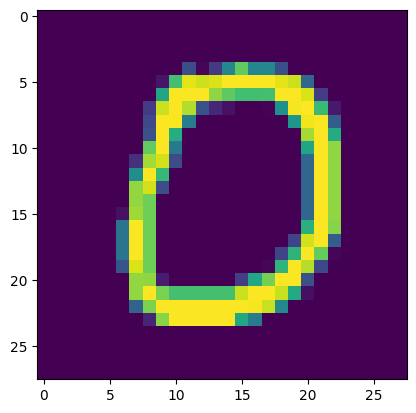

In [ ]:
element =10


img1 = x_test[element]
plt.imshow(img1)
print(df.iloc[element])

In [ ]:
# CConfusion matrix + per-class accuracy
from sklearn.metrics import confusion_matrix, classification_report

y_prob = history.predict(X_test, verbose=0)
y_pred = y_prob.argmax(1)
y_true = y_test.argmax(1)
print(confusion_matrix(y_true, y_pred))
print(classification_report(y_true, y_pred))

AttributeError: 'History' object has no attribute 'predict'